[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bsheese/225/blob/main/11_time/11_1_Time_Series_Basics.ipynb)

# 11.1: Time Series Basics: Dates as an Index

Imagine you manage a bike-sharing program in Washington DC. You have two years of daily records showing how many bikes were rented each day. The question you most want to answer is simple: how did ridership change across those two years, and when during the year was demand highest?

A plain table of numbers will not answer that question well. You need pandas to understand that the rows are ordered in time, that `2012-07-15` comes after `2012-07-14`, and that "the previous week" means something specific. This notebook shows you how to give pandas that understanding.

This module switches from the Gapminder dataset used in modules 9 and 10 to a bike-sharing dataset. Gapminder worked well for groupby and SQL queries across 142 countries, but time-series tools require data collected at regular intervals over many consecutive periods. The Washington DC bike-sharing records — one row per day for 731 consecutive days — fit that requirement exactly.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/bsheese/225/main/data/bike_daily.csv"
df_raw = pd.read_csv(url)
keep = ["dteday", "season", "yr", "mnth", "holiday", "weekday",
        "workingday", "weathersit", "temp", "casual", "registered", "cnt"]
df = df_raw[keep].copy()
df.head()

,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,casual,registered,cnt
0,2011-01-01,1,0,1,0,6,0,2,0.344167,331,654,985
1,2011-01-02,1,0,1,0,0,0,2,0.363478,131,670,801
2,2011-01-03,1,0,1,0,1,1,1,0.196364,120,1229,1349
3,2011-01-04,1,0,1,0,2,1,1,0.200000,108,1454,1562
4,2011-01-05,1,0,1,0,3,1,1,0.226957,82,1518,1600


## Parsing dates: from string to datetime

When pandas loads a CSV, it reads every column as text unless told otherwise. The `dteday` column contains date strings like `"2011-01-01"`, but as far as pandas is concerned right now, they are no different from the string `"hello"`. You cannot subtract one from another, you cannot ask pandas to group by month, and if you plot the column you get a line of text labels rather than a timeline.

`pd.to_datetime()` converts a column of date strings into a proper datetime dtype. After the conversion, pandas knows that `2011-01-01` is a date, not text.

In [2]:
print("Before:", df["dteday"].dtype)
df["dteday"] = pd.to_datetime(df["dteday"])
print("After: ", df["dteday"].dtype)
df["dteday"].head()

Before: str
After:  datetime64[us]


0   2011-01-01
1   2011-01-02
2   2011-01-03
3   2011-01-04
4   2011-01-05
Name: dteday, dtype: datetime64[us]

The dtype changed from `object` (pandas' label for text) to `datetime64[ns]`. The values look the same on screen, but pandas now treats them as timestamps. You can do date arithmetic, extract the month with `.dt.month`, and compare dates using `>` and `<`.

## Setting the date as the index

In a regular DataFrame, the index is just a row number (0, 1, 2, ...). For time series data, the date is a much better index. When the date is the index, pandas can slice the DataFrame by year or month using simple string notation, align two series automatically by time, and pass date labels to matplotlib for clean x-axis tick marks.

`set_index("dteday")` replaces the default integer index with the date column. `sort_index()` ensures the rows are in chronological order, which is a good habit even when the data arrives sorted.

In [ ]:
df = df.set_index("dteday").sort_index()
df.to_parquet("bike_daily.parquet")
df.head()

The row labels are now dates. The `dteday` column no longer appears as a regular column because it has become the index. The first date is January 1, 2011, and the rows run forward in time from there.

## Seeing two years at once

With the date index in place, plotting the full rental history takes one line.

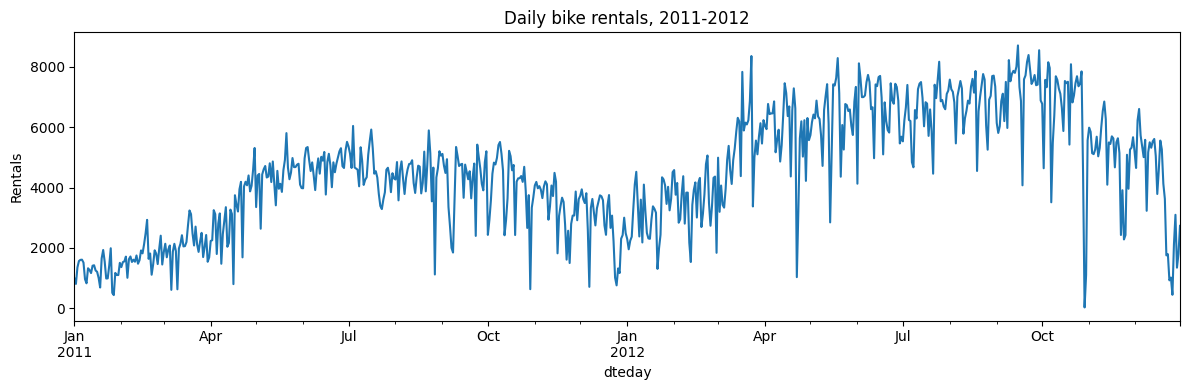

In [4]:
df["cnt"].plot(figsize=(12, 4), title="Daily bike rentals, 2011-2012", ylabel="Rentals")
plt.tight_layout()

The x-axis shows dates automatically because the index is a `DatetimeIndex`. The seasonal pattern is immediately visible: ridership rises each spring, peaks in summer, then drops through fall and winter. The 2012 peak is noticeably higher than the 2011 peak, which suggests overall growth from year to year. Isolated sharp drops correspond to days with very low rental counts, likely due to bad weather. We will investigate both patterns in detail in the notebooks ahead.

## Selecting rows by date string

Because the index is a `DatetimeIndex`, you can select rows using a plain date string. No boolean mask required.

In [5]:
# All rows from 2011
y2011 = df.loc["2011"]
print("2011 rows:", len(y2011))

# All rows from June 2011
june_2011 = df.loc["2011-06"]
print("June 2011 rows:", len(june_2011))

june_2011[["cnt", "temp"]].head()

2011 rows: 365
June 2011 rows: 30


,cnt,temp
dteday,,
2011-06-01,3974,0.764167
2011-06-02,4968,0.715000
2011-06-03,5312,0.620000
2011-06-04,5342,0.635000
2011-06-05,4906,0.648333


`df.loc["2011"]` returns all 365 rows from 2011. `df.loc["2011-06"]` returns the 30 rows from June 2011. This partial-string indexing works only when the index is a `DatetimeIndex`. With an integer index, `df.loc["2011"]` would raise a `KeyError`. The precision you specify determines the window: a four-digit year matches the whole year; a `YYYY-MM` string matches a single month.

## Confirming the date range

Before doing any analysis, it is worth confirming that the dataset covers exactly the dates you expect.

In [6]:
print("First date:", df.index.min().date())
print("Last date: ", df.index.max().date())
print("Total rows:", len(df))

First date: 2011-01-01
Last date:  2012-12-31
Total rows: 731


The dataset runs from January 1, 2011 through December 31, 2012. 731 rows = 365 days in 2011 plus 366 days in 2012 (a leap year). There are no gaps: every calendar day has exactly one row. This clean, gapless structure is what makes the later resampling and rolling-window operations work without any extra handling.

## What's next

You can now navigate time series data: load a CSV with date strings, convert them to datetime, set the date as the index, and slice by year or month. The plot already hints at a seasonal pattern and year-over-year growth, but the daily line is noisy. In notebook 11.2 you will learn to resample: how to roll the daily data up to weekly or monthly summaries to see the large-scale shape more clearly.